# BMW Dealer Inventory: Sold Analysis (Feb 7 → Feb 26, 2026)

This notebook compares two inventory snapshots to identify which vehicles sold between Feb 7 and Feb 26, 2026, and provides a full picture of inventory movement.

### Methodology
A Feb 7 **DEALER INVENTORY** vehicle is classified as **sold** if by Feb 26 it:
- Dropped off the dataset entirely (left the lot), **OR**
- Has `sold = True` in the Feb 26 snapshot, **OR**
- Has `darstatus = '0-RETAIL'` in the Feb 26 snapshot

**Estimated sale window:** Feb 7–26, 2026 (19 days). Since `solddate` is corrupted in the source data, the midpoint **Feb 16, 2026** is used as a point estimate for sold date.

### Sections
1. Setup & data loading
2. Build sold/unsold classification
3. Sold vehicles — who moved and what profile?
4. Dealer inventory snapshot comparison (Feb 7 vs Feb 26)
5. Days on lot distribution
6. New arrivals between snapshots

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings('ignore')

# BMW color palette
BMW_BLUE   = '#1C69D4'
BMW_DARK   = '#1A1A1A'
BMW_GRAY   = '#6D6D6D'
BMW_LIGHT  = '#E8E8E8'
SOLD_COLOR = '#D4A017'
UNSOLD_COLOR = '#1C69D4'
NEW_COLOR  = '#2ECC71'

SNAP_FEB7  = pd.Timestamp('2026-02-07')
SNAP_FEB26 = pd.Timestamp('2026-02-26')
SOLD_MID   = pd.Timestamp('2026-02-16')   # midpoint estimate for sold date

# Load both snapshots
df07 = pd.read_csv('inventorydata/invsearchvehicles-02072026.csv', low_memory=False)
df26 = pd.read_csv('invsearchvehicles-02262026.csv', low_memory=False)

# Replace NULL strings
df07 = df07.replace('NULL', np.nan)
df26 = df26.replace('NULL', np.nan)

print(f'Feb  7 snapshot: {len(df07):,} total vehicles')
print(f'Feb 26 snapshot: {len(df26):,} total vehicles')
print()
print('Feb  7 darstatus breakdown:')
print(df07['darstatus'].value_counts().to_string())
print()
print('Feb 26 darstatus breakdown:')
print(df26['darstatus'].value_counts().to_string())

Feb  7 snapshot: 1,535 total vehicles
Feb 26 snapshot: 4,668 total vehicles

Feb  7 darstatus breakdown:
darstatus
1-DEALER INVENTORY                  662
6-ON ORDER                          621
5-SCHEDULED FOR OR IN PRODUCTION    174
2-AT PROCESSING CENTER               53
0-RETAIL                             21
3-IN TRANSIT TO VPC                   4

Feb 26 darstatus breakdown:
darstatus
1-DEALER INVENTORY                  3750
6-ON ORDER                           407
5-SCHEDULED FOR OR IN PRODUCTION     330
2-AT PROCESSING CENTER               132
0-RETAIL                              45
3-IN TRANSIT TO VPC                    4


## 2. Build Sold / Unsold Classification

Starting from the 662 vehicles that were **DEALER INVENTORY** on Feb 7, we determine their fate by Feb 26.

In [2]:
# Feb 7 dealer inventory
di07 = df07[df07['darstatus'] == '1-DEALER INVENTORY'].copy()
di07['dealeractualarrivaldate'] = pd.to_datetime(di07['dealeractualarrivaldate'], format='mixed', errors='coerce')
di07['days_on_lot_feb7'] = (SNAP_FEB7 - di07['dealeractualarrivaldate']).dt.days.clip(lower=0)

# Pull Feb 26 status for those vehicles
status26 = df26[df26['id'].isin(di07['id'])][['id', 'darstatus', 'sold']].copy()
status26.columns = ['id', 'darstatus_feb26', 'sold_feb26']

di07 = di07.merge(status26, on='id', how='left')

# Classify
di07['in_feb26'] = di07['id'].isin(set(df26['id']))
di07['sold'] = (
    ~di07['in_feb26'] |
    (di07['sold_feb26'] == True) |
    (di07['darstatus_feb26'] == '0-RETAIL')
)

# Estimated sold date (midpoint of window for all sold vehicles)
di07['est_sold_date'] = np.where(di07['sold'], SOLD_MID, pd.NaT)
di07['est_sold_date'] = pd.to_datetime(di07['est_sold_date'])

# Days on lot at sale
di07['days_on_lot_at_sale'] = np.where(
    di07['sold'],
    (SOLD_MID - di07['dealeractualarrivaldate']).dt.days.clip(lower=0),
    np.nan
)

sold    = di07[di07['sold'] == True].copy()
unsold  = di07[di07['sold'] == False].copy()

print(f'Feb 7 dealer inventory:  {len(di07):,} vehicles')
print(f'  Sold by Feb 26:        {len(sold):,} vehicles  ({len(sold)/len(di07)*100:.1f}%)')
print(f'  Still on lot Feb 26:   {len(unsold):,} vehicles  ({len(unsold)/len(di07)*100:.1f}%)')
print()
print('Sold vehicle breakdown by reason:')
print(f'  Dropped off dataset entirely: {(~di07[di07["sold"]]["in_feb26"]).sum()}')
print(f'  sold=True flag in Feb 26:     {(di07[di07["sold"]]["sold_feb26"] == True).sum()}')
print(f'  darstatus→0-RETAIL:           {(di07[di07["sold"]]["darstatus_feb26"] == "0-RETAIL").sum()}')

Feb 7 dealer inventory:  662 vehicles
  Sold by Feb 26:        172 vehicles  (26.0%)
  Still on lot Feb 26:   490 vehicles  (74.0%)

Sold vehicle breakdown by reason:
  Dropped off dataset entirely: 57
  sold=True flag in Feb 26:     112
  darstatus→0-RETAIL:           3


## 3. Sold Vehicles — Profile & Breakdown

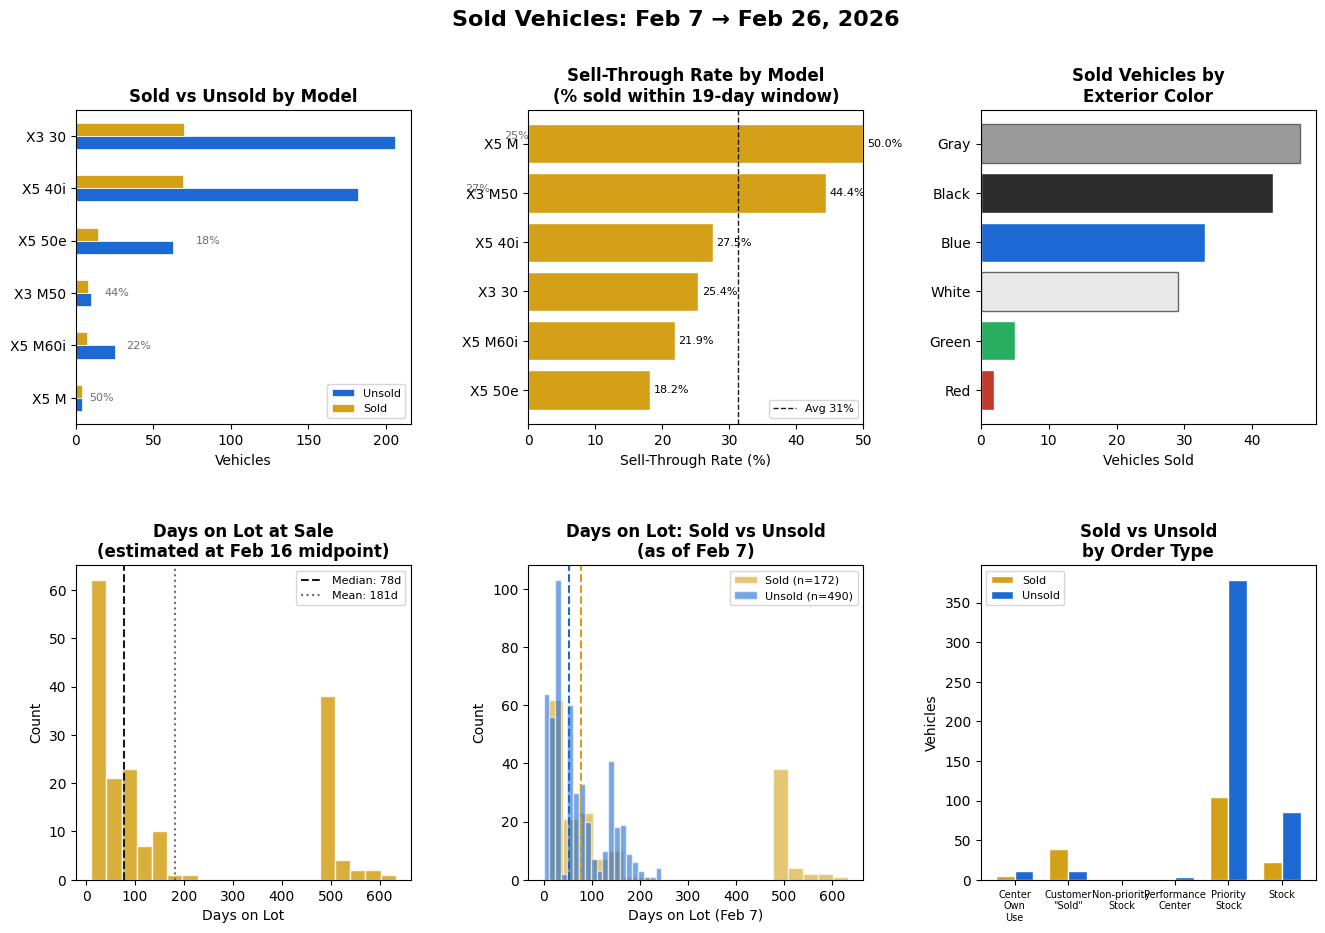

Saved: sold_analysis.png


In [3]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Sold Vehicles: Feb 7 → Feb 26, 2026', fontsize=16, fontweight='bold', y=0.98)
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Model breakdown (sold vs unsold) ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
models = di07.groupby(['modeldescription', 'sold']).size().unstack(fill_value=0)
models.columns = ['Unsold', 'Sold']
models = models.sort_values('Sold', ascending=True)
models.plot(kind='barh', ax=ax1, color=[UNSOLD_COLOR, SOLD_COLOR], edgecolor='white', linewidth=0.5)
ax1.set_title('Sold vs Unsold by Model', fontweight='bold')
ax1.set_xlabel('Vehicles')
ax1.set_ylabel('')
ax1.legend(loc='lower right', fontsize=8)
# Add sell-through rate labels
for i, (idx, row) in enumerate(models.iterrows()):
    total = row['Sold'] + row['Unsold']
    rate = row['Sold'] / total * 100
    ax1.text(total + 0.5, i, f'{rate:.0f}%', va='center', fontsize=8, color=BMW_GRAY)

# ── 2. Sell-through rate by model (%) ────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sell_rate = (models['Sold'] / (models['Sold'] + models['Unsold']) * 100).sort_values()
bars = ax2.barh(sell_rate.index, sell_rate.values, color=SOLD_COLOR, edgecolor='white')
ax2.axvline(sell_rate.mean(), color=BMW_DARK, linestyle='--', linewidth=1, label=f'Avg {sell_rate.mean():.0f}%')
ax2.set_title('Sell-Through Rate by Model\n(% sold within 19-day window)', fontweight='bold')
ax2.set_xlabel('Sell-Through Rate (%)')
ax2.set_xlim(0, 50)
ax2.legend(fontsize=8)
for bar, val in zip(bars, sell_rate.values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8)

# ── 3. Exterior color of sold vehicles ───────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
color_map = {
    'Black': '#2C2C2C', 'White': '#E8E8E8', 'Gray': '#9B9B9B',
    'Blue': '#1C69D4', 'Red': '#C0392B', 'Green': '#27AE60', 'Brown': '#8B4513'
}
sold_colors = sold['exteriorgenericcolor'].value_counts().dropna()
bar_colors = [color_map.get(c, '#AAAAAA') for c in sold_colors.index]
edge_colors = ['#666666' if c in ('#E8E8E8', '#9B9B9B') else 'white' for c in bar_colors]
ax3.barh(sold_colors.index[::-1], sold_colors.values[::-1], color=bar_colors[::-1], edgecolor=edge_colors[::-1])
ax3.set_title('Sold Vehicles by\nExterior Color', fontweight='bold')
ax3.set_xlabel('Vehicles Sold')

# ── 4. Days on lot at time of sale ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
dol_sold = sold['days_on_lot_at_sale'].dropna()
ax4.hist(dol_sold, bins=20, color=SOLD_COLOR, edgecolor='white', alpha=0.85)
ax4.axvline(dol_sold.median(), color=BMW_DARK, linestyle='--', linewidth=1.5, label=f'Median: {dol_sold.median():.0f}d')
ax4.axvline(dol_sold.mean(), color=BMW_GRAY, linestyle=':', linewidth=1.5, label=f'Mean: {dol_sold.mean():.0f}d')
ax4.set_title('Days on Lot at Sale\n(estimated at Feb 16 midpoint)', fontweight='bold')
ax4.set_xlabel('Days on Lot')
ax4.set_ylabel('Count')
ax4.legend(fontsize=8)

# ── 5. Days on lot: sold vs unsold comparison ─────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
dol_unsold = unsold['days_on_lot_feb7'].dropna()
ax5.hist(dol_sold, bins=20, color=SOLD_COLOR, edgecolor='white', alpha=0.6, label=f'Sold (n={len(dol_sold)})')
ax5.hist(dol_unsold, bins=20, color=UNSOLD_COLOR, edgecolor='white', alpha=0.6, label=f'Unsold (n={len(dol_unsold)})')
ax5.axvline(dol_sold.median(), color=SOLD_COLOR, linestyle='--', linewidth=1.5)
ax5.axvline(dol_unsold.median(), color=UNSOLD_COLOR, linestyle='--', linewidth=1.5)
ax5.set_title('Days on Lot: Sold vs Unsold\n(as of Feb 7)', fontweight='bold')
ax5.set_xlabel('Days on Lot (Feb 7)')
ax5.set_ylabel('Count')
ax5.legend(fontsize=8)

# ── 6. Sold by order type ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
sold_ot = sold['ordertype'].value_counts().dropna()
unsold_ot = unsold['ordertype'].value_counts().dropna()
all_ot = sorted(set(sold_ot.index) | set(unsold_ot.index))
sold_vals = [sold_ot.get(o, 0) for o in all_ot]
unsold_vals = [unsold_ot.get(o, 0) for o in all_ot]
x = np.arange(len(all_ot))
w = 0.35
ax6.bar(x - w/2, sold_vals, w, label='Sold', color=SOLD_COLOR, edgecolor='white')
ax6.bar(x + w/2, unsold_vals, w, label='Unsold', color=UNSOLD_COLOR, edgecolor='white')
ax6.set_xticks(x)
ax6.set_xticklabels([o.replace(' ', '\n') for o in all_ot], fontsize=7)
ax6.set_title('Sold vs Unsold\nby Order Type', fontweight='bold')
ax6.set_ylabel('Vehicles')
ax6.legend(fontsize=8)

plt.savefig('sold_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: sold_analysis.png')

In [4]:
# Sold vehicles detail table
display_cols = [
    'id', 'modeldescription', 'modelyear', 'exteriorgenericcolor',
    'interiorgenericcolor', 'powertrain', 'ordertype',
    'totalmsrp', 'days_on_lot_feb7', 'days_on_lot_at_sale',
    'est_sold_date', 'in_feb26', 'sold_feb26', 'darstatus_feb26'
]
available = [c for c in display_cols if c in sold.columns]

print(f'SOLD VEHICLES — {len(sold)} total (Feb 7 → Feb 26, 2026)')
print('=' * 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 200)
print(sold[available].sort_values('modeldescription').to_string(index=False))

SOLD VEHICLES — 172 total (Feb 7 → Feb 26, 2026)
      id modeldescription  modelyear exteriorgenericcolor interiorgenericcolor                          powertrain          ordertype  totalmsrp  days_on_lot_feb7  days_on_lot_at_sale est_sold_date  in_feb26 sold_feb26    darstatus_feb26
63941835            X3 30       2026                White                Black              xDrive all-wheel drive              Stock          0                 3                 12.0    2026-02-16      True       True 1-DEALER INVENTORY
63811131            X3 30       2026                Black                Black              xDrive all-wheel drive     Priority Stock          0                77                 86.0    2026-02-16      True       True 1-DEALER INVENTORY
63811149            X3 30       2026                 Gray                Black              xDrive all-wheel drive     Priority Stock          0                32                 41.0    2026-02-16      True       True 1-DEALER INVENTORY

## 4. Dealer Inventory Snapshot Comparison

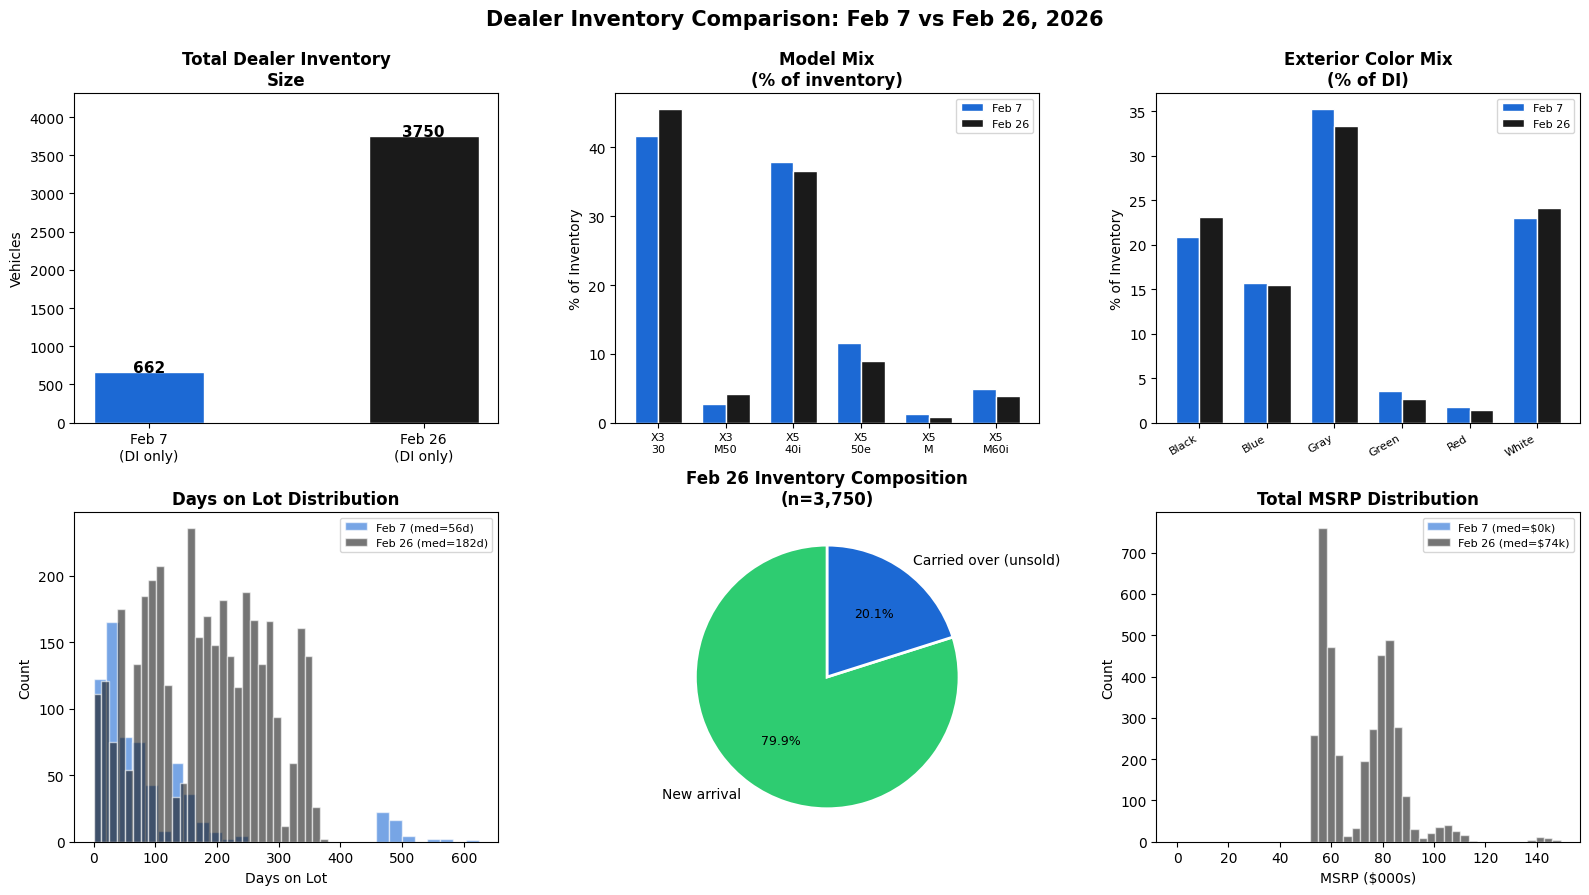

Saved: inventory_comparison.png


In [5]:
di26 = df26[df26['darstatus'] == '1-DEALER INVENTORY'].copy()
di26['dealeractualarrivaldate'] = pd.to_datetime(di26['dealeractualarrivaldate'], format='mixed', errors='coerce')
di26['days_on_lot_feb26'] = (SNAP_FEB26 - di26['dealeractualarrivaldate']).dt.days.clip(lower=0)

# Tag vehicles in Feb 26 by their history
di26['status'] = 'Carried over (unsold)'
new_ids = set(di26['id']) - set(df07['id'])
di26.loc[di26['id'].isin(new_ids), 'status'] = 'New arrival'

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dealer Inventory Comparison: Feb 7 vs Feb 26, 2026', fontsize=15, fontweight='bold', y=0.99)

# ── 1. Total inventory size ───────────────────────────────────────────────────
ax = axes[0, 0]
labels = ['Feb 7\n(DI only)', 'Feb 26\n(DI only)']
vals = [len(di07), len(di26)]
colors_bar = [BMW_BLUE, BMW_DARK]
bars = ax.bar(labels, vals, color=colors_bar, width=0.4, edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center', fontweight='bold', fontsize=11)
ax.set_title('Total Dealer Inventory\nSize', fontweight='bold')
ax.set_ylabel('Vehicles')
ax.set_ylim(0, max(vals) * 1.15)

# ── 2. Model mix comparison ───────────────────────────────────────────────────
ax = axes[0, 1]
m07 = di07['modeldescription'].value_counts(normalize=True) * 100
m26 = di26['modeldescription'].value_counts(normalize=True) * 100
all_models = sorted(set(m07.index) | set(m26.index))
x = np.arange(len(all_models))
w = 0.35
ax.bar(x - w/2, [m07.get(m, 0) for m in all_models], w, label='Feb 7', color=BMW_BLUE, edgecolor='white')
ax.bar(x + w/2, [m26.get(m, 0) for m in all_models], w, label='Feb 26', color=BMW_DARK, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' ', '\n') for m in all_models], fontsize=8)
ax.set_title('Model Mix\n(% of inventory)', fontweight='bold')
ax.set_ylabel('% of Inventory')
ax.legend(fontsize=8)

# ── 3. Exterior color mix ─────────────────────────────────────────────────────
ax = axes[0, 2]
c07 = di07['exteriorgenericcolor'].value_counts(normalize=True).dropna() * 100
c26 = di26['exteriorgenericcolor'].value_counts(normalize=True).dropna() * 100
all_colors = sorted(set(c07.index) | set(c26.index))
x = np.arange(len(all_colors))
ax.bar(x - w/2, [c07.get(c, 0) for c in all_colors], w, label='Feb 7', color=BMW_BLUE, edgecolor='white')
ax.bar(x + w/2, [c26.get(c, 0) for c in all_colors], w, label='Feb 26', color=BMW_DARK, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(all_colors, fontsize=8, rotation=30, ha='right')
ax.set_title('Exterior Color Mix\n(% of DI)', fontweight='bold')
ax.set_ylabel('% of Inventory')
ax.legend(fontsize=8)

# ── 4. Days on lot distribution ───────────────────────────────────────────────
ax = axes[1, 0]
ax.hist(di07['days_on_lot_feb7'].dropna(), bins=30, color=BMW_BLUE, alpha=0.6, edgecolor='white', label=f'Feb 7 (med={di07["days_on_lot_feb7"].median():.0f}d)')
ax.hist(di26['days_on_lot_feb26'].dropna(), bins=30, color=BMW_DARK, alpha=0.6, edgecolor='white', label=f'Feb 26 (med={di26["days_on_lot_feb26"].median():.0f}d)')
ax.set_title('Days on Lot Distribution', fontweight='bold')
ax.set_xlabel('Days on Lot')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

# ── 5. Feb 26 inventory: new arrivals vs carried over ─────────────────────────
ax = axes[1, 1]
status_counts = di26['status'].value_counts()
wedge_colors = [NEW_COLOR, BMW_BLUE]
wedges, texts, autotexts = ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=wedge_colors[:len(status_counts)],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title(f'Feb 26 Inventory Composition\n(n={len(di26):,})', fontweight='bold')

# ── 6. MSRP distribution ──────────────────────────────────────────────────────
ax = axes[1, 2]
msrp07 = pd.to_numeric(di07['totalmsrp'], errors='coerce').dropna() / 1000
msrp26 = pd.to_numeric(di26['totalmsrp'], errors='coerce').dropna() / 1000
ax.hist(msrp07, bins=30, color=BMW_BLUE, alpha=0.6, edgecolor='white', label=f'Feb 7 (med=${msrp07.median():.0f}k)')
ax.hist(msrp26, bins=30, color=BMW_DARK, alpha=0.6, edgecolor='white', label=f'Feb 26 (med=${msrp26.median():.0f}k)')
ax.set_title('Total MSRP Distribution', fontweight='bold')
ax.set_xlabel('MSRP ($000s)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('inventory_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: inventory_comparison.png')

## 5. Days on Lot — Aging Analysis

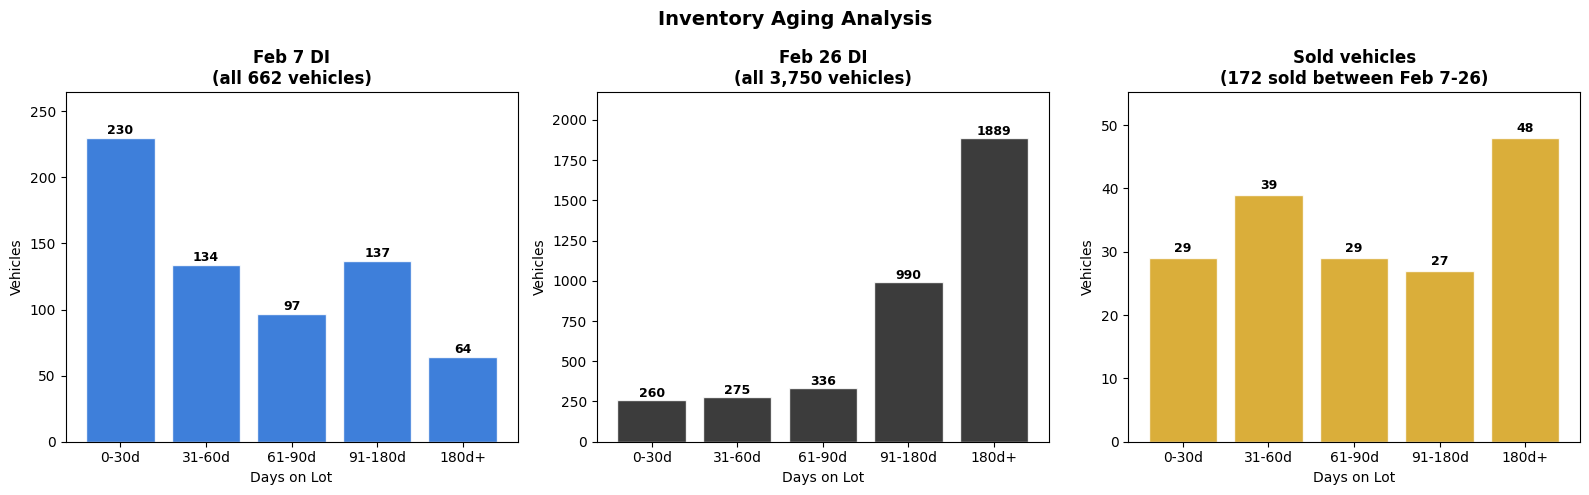

Saved: aging_analysis.png


In [6]:
# Aging buckets
def aging_bucket(days):
    if pd.isna(days): return 'Unknown'
    if days <= 30:  return '0-30d'
    if days <= 60:  return '31-60d'
    if days <= 90:  return '61-90d'
    if days <= 180: return '91-180d'
    return '180d+'

bucket_order = ['0-30d', '31-60d', '61-90d', '91-180d', '180d+']

di07['aging_bucket'] = di07['days_on_lot_feb7'].apply(aging_bucket)
di26['aging_bucket'] = di26['days_on_lot_feb26'].apply(aging_bucket)
sold['aging_bucket'] = sold['days_on_lot_at_sale'].apply(aging_bucket)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Inventory Aging Analysis', fontsize=14, fontweight='bold')

for ax, (data, title, color) in zip(axes, [
    (di07, 'Feb 7 DI\n(all 662 vehicles)', BMW_BLUE),
    (di26, 'Feb 26 DI\n(all 3,750 vehicles)', BMW_DARK),
    (sold, 'Sold vehicles\n(172 sold between Feb 7-26)', SOLD_COLOR),
]):
    counts = data['aging_bucket'].value_counts().reindex(bucket_order, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=color, edgecolor='white', alpha=0.85)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Days on Lot')
    ax.set_ylabel('Vehicles')
    ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.savefig('aging_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: aging_analysis.png')

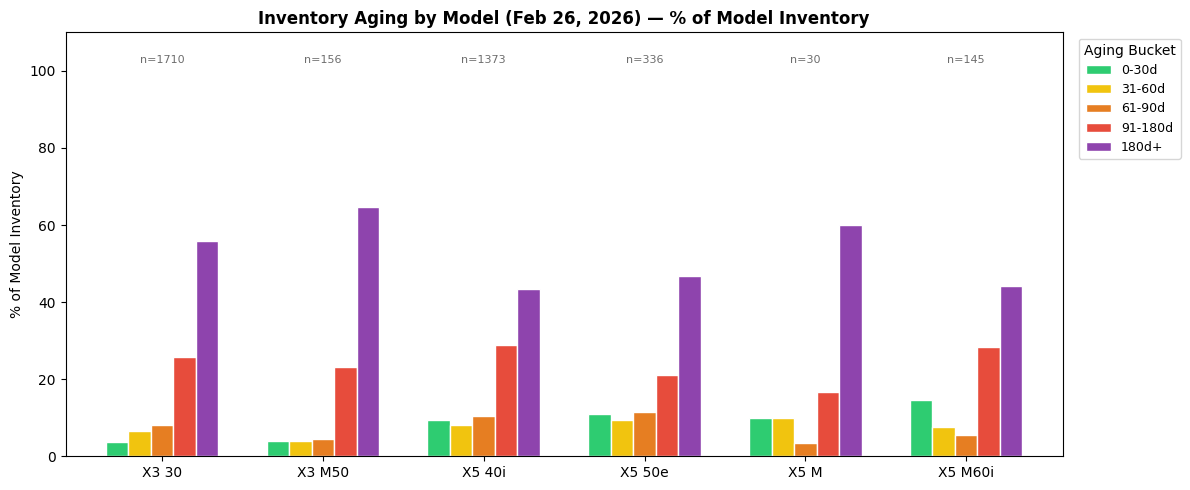

In [7]:
# Aging by model for Feb 26
fig, ax = plt.subplots(figsize=(12, 5))

pivot = di26.groupby(['modeldescription', 'aging_bucket']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=bucket_order, fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

bar_colors = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C', '#8E44AD']
pivot_pct.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='white', width=0.7)

ax.set_title('Inventory Aging by Model (Feb 26, 2026) — % of Model Inventory', fontweight='bold')
ax.set_xlabel('')
ax.set_xticklabels(pivot_pct.index, rotation=0)
ax.set_ylabel('% of Model Inventory')
ax.legend(title='Aging Bucket', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 110)

# Add count annotation on bars
for i, model in enumerate(pivot.index):
    total = pivot.loc[model].sum()
    ax.text(i, 102, f'n={total}', ha='center', fontsize=8, color=BMW_GRAY)

plt.tight_layout()
plt.savefig('aging_by_model.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. New Arrivals Between Snapshots

New vehicles in Feb 26 DI that were not in Feb 7 at all: 2,996



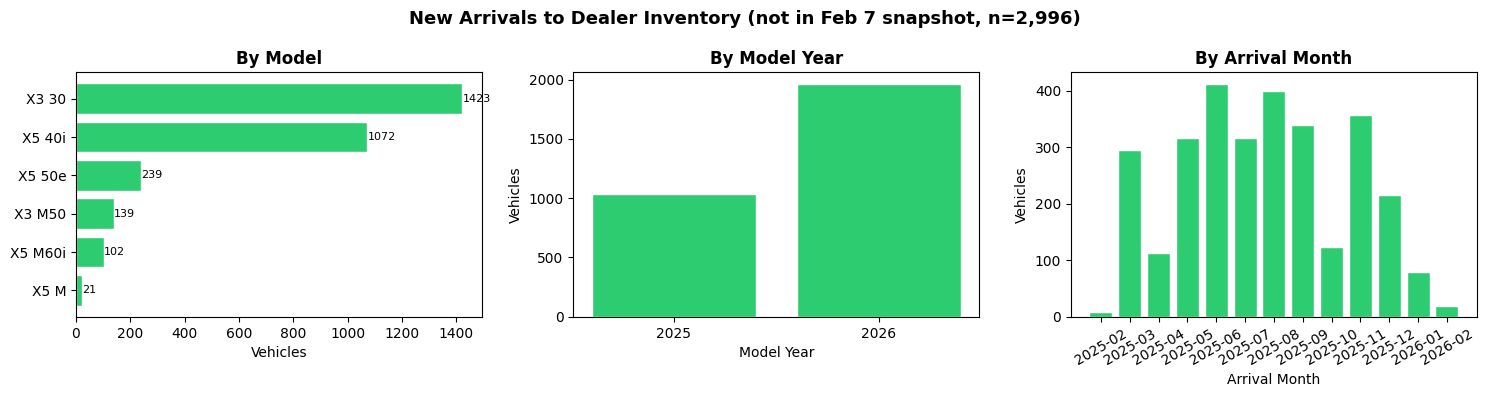

In [8]:
new_arrivals = di26[di26['id'].isin(new_ids)].copy()
print(f'New vehicles in Feb 26 DI that were not in Feb 7 at all: {len(new_arrivals):,}')
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'New Arrivals to Dealer Inventory (not in Feb 7 snapshot, n={len(new_arrivals):,})',
             fontsize=13, fontweight='bold')

# Model breakdown of new arrivals
ax = axes[0]
na_models = new_arrivals['modeldescription'].value_counts()
ax.barh(na_models.index[::-1], na_models.values[::-1], color=NEW_COLOR, edgecolor='white')
ax.set_title('By Model', fontweight='bold')
ax.set_xlabel('Vehicles')
for i, v in enumerate(na_models.values[::-1]):
    ax.text(v + 1, i, str(v), va='center', fontsize=8)

# Model year of new arrivals
ax = axes[1]
na_year = new_arrivals['modelyear'].value_counts().sort_index()
ax.bar(na_year.index.astype(str), na_year.values, color=NEW_COLOR, edgecolor='white')
ax.set_title('By Model Year', fontweight='bold')
ax.set_xlabel('Model Year')
ax.set_ylabel('Vehicles')

# Arrival month
ax = axes[2]
na_month = new_arrivals['dealeractualarrivaldate'].dt.to_period('M').value_counts().sort_index()
ax.bar(na_month.index.astype(str), na_month.values, color=NEW_COLOR, edgecolor='white')
ax.set_title('By Arrival Month', fontweight='bold')
ax.set_xlabel('Arrival Month')
ax.set_ylabel('Vehicles')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('new_arrivals.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 7. Summary Statistics

In [9]:
print('=' * 60)
print('INVENTORY MOVEMENT SUMMARY: Feb 7 → Feb 26, 2026')
print('=' * 60)
print(f'\nStarting inventory (Feb 7 DI):        {len(di07):>5,}')
print(f'  Sold between Feb 7-26:              {len(sold):>5,}  ({len(sold)/len(di07)*100:.1f}%)')
print(f'  Carried over to Feb 26:             {len(unsold):>5,}  ({len(unsold)/len(di07)*100:.1f}%)')
print(f'\nFeb 26 dealer inventory total:        {len(di26):>5,}')
print(f'  Carried over (unsold from Feb 7):   {len(di26) - len(new_arrivals):>5,}')
print(f'  New arrivals:                       {len(new_arrivals):>5,}')
print()
print('SOLD VEHICLE STATS')
print('-' * 40)
print(f'  Median days on lot at sale:  {sold["days_on_lot_at_sale"].median():.0f} days')
print(f'  Mean days on lot at sale:    {sold["days_on_lot_at_sale"].mean():.0f} days')
print(f'  Sell-through rate (19-day window): {len(sold)/len(di07)*100:.1f}%')
print()
print('SELL-THROUGH BY MODEL')
print('-' * 40)
for model in sorted(di07['modeldescription'].dropna().unique()):
    total = (di07['modeldescription'] == model).sum()
    n_sold = ((di07['modeldescription'] == model) & di07['sold']).sum()
    print(f'  {model:20s}  {n_sold:3d}/{total:3d}  ({n_sold/total*100:.1f}%)')
print()
print('EST. SOLD DATE NOTE')
print('-' * 40)
print('  solddate column is corrupted in source data.')
print(f'  All sold vehicles are assigned est_sold_date = {SOLD_MID.date()}')
print(f'  (midpoint of the Feb 7 – Feb 26 observation window)')

INVENTORY MOVEMENT SUMMARY: Feb 7 → Feb 26, 2026

Starting inventory (Feb 7 DI):          662
  Sold between Feb 7-26:                172  (26.0%)
  Carried over to Feb 26:               490  (74.0%)

Feb 26 dealer inventory total:        3,750
  Carried over (unsold from Feb 7):     754
  New arrivals:                       2,996

SOLD VEHICLE STATS
----------------------------------------
  Median days on lot at sale:  78 days
  Mean days on lot at sale:    181 days
  Sell-through rate (19-day window): 26.0%

SELL-THROUGH BY MODEL
----------------------------------------
  X3 30                  70/276  (25.4%)
  X3 M50                  8/ 18  (44.4%)
  X5 40i                 69/251  (27.5%)
  X5 50e                 14/ 77  (18.2%)
  X5 M                    4/  8  (50.0%)
  X5 M60i                 7/ 32  (21.9%)

EST. SOLD DATE NOTE
----------------------------------------
  solddate column is corrupted in source data.
  All sold vehicles are assigned est_sold_date = 2026-02-16
  (mi